# Speckle Óptico a Distancias Reales - Generación Estadística (Goodman)
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | Maestría en Ciencias de la Computación - UJAT
**Director:** Dr. José Adán Hernández Nolasco

---

Genera y valida estadísticamente el patrón de speckle a **10 distancias físicas
reales** (2-20 cm, paso 2cm), acordado con el asesor en la reunión del 2026-09-08
("máximo unos 20cm... 10 lambdas... busca en internet qué distancia manejan
[los experimentos reales]").

**Importante - qué es y qué NO es este notebook:**
- **NO** es una propagación de onda (no resuelve la ecuación de Helmholtz con
  PINN). Es una **generación estadística**: se construye directamente un campo
  con las propiedades que la teoría de Goodman predice (contraste C=1, tamaño
  de grano = lambda*z/D), sin derivarlas de la física de difracción.
- Se descartó la propagación de onda exacta (método del espectro angular) tras
  comprobar que, sin una apertura con borde finito (margen oscuro alrededor de
  la zona iluminada), la FFT trata el campo como periódico infinito y elimina el
  mecanismo de difracción que genera el grano.
- Un intento previo de generar speckle resolviendo Helmholtz con PINN y frontera
  de fase aleatoria (dominio de 1 longitud de onda) mostró que a esa escala solo
  3 de 256 modos de la frontera logran propagar, y el campo resultante no
  desarrolla speckle real (ver diagnóstico en
  scripts/experiments/diagnose_nb03_speckle_regime.py). Este notebook, con
  generación estadística directa, es la validación de speckle que sostiene la
  Hipótesis (iii) y el Objetivo específico 4 de la tesis: contraste C y
  distribución exponencial (test KS) verificados en las 10 distancias.

## 0. Imports y configuración

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

import sys
sys.path.insert(0, os.path.join('..'))
from src.utils import get_figures_dir

LAMBDA = 638e-9       # laser diodo rojo, m (CLAUDE.md)
D = 2e-3              # ancho de iluminacion, m (Andres-Zarate/Hernandez-Nolasco 2019: aberturas ~1-1.5mm de radio)
SEED = 42             # misma semilla global del proyecto
DISTANCES_CM = list(range(2, 21, 2))  # 2,4,...,20 cm (10 distancias, acordadas con el asesor)
WINDOW_M = D
N_GRID = 1024

IMG_DIR = get_figures_dir() / 'speckle_distances'
IMG_DIR.mkdir(parents=True, exist_ok=True)
print('Figuras en:', IMG_DIR)

Figuras en: C:\roberto\Tesis_Maestria\results\figures\speckle_distances


## 1. Tamaño de grano teórico (Goodman, 2007)

$$\text{grano} \approx \frac{\lambda z}{D}$$

donde $D$ es el ancho de la zona iluminada y $z$ la distancia de propagación.
Esta es la misma fórmula ya citada en `Cap2-Marcos.tex` / `goodman2007speckle` -
aquí se usa para *fijar* el ancho del filtro que genera el campo, no para
validar una simulación de propagación.

In [2]:
def grain_size_theoretical(z_m, D_m=D, wavelength=LAMBDA):
    """Tamano de grano de speckle objetivo, Goodman (2007): ~ lambda*z / D."""
    return wavelength * z_m / D_m

for z_cm in DISTANCES_CM:
    g = grain_size_theoretical(z_cm * 1e-2)
    print(f'  z={z_cm:2d}cm  grano teorico = {g*1e6:.2f} um')

  z= 2cm  grano teorico = 6.38 um
  z= 4cm  grano teorico = 12.76 um
  z= 6cm  grano teorico = 19.14 um
  z= 8cm  grano teorico = 25.52 um
  z=10cm  grano teorico = 31.90 um
  z=12cm  grano teorico = 38.28 um
  z=14cm  grano teorico = 44.66 um
  z=16cm  grano teorico = 51.04 um
  z=18cm  grano teorico = 57.42 um
  z=20cm  grano teorico = 63.80 um


## 2. Generación del campo de speckle

Ruido blanco complejo gaussiano ($a+ib$, $a,b\sim\mathcal{N}(0,1)$ i.i.d.) filtrado
en frecuencia con un filtro gaussiano cuyo ancho fija el grano deseado. El
filtrado lineal de ruido gaussiano produce un campo gaussiano circular (Goodman,
2007) - por construcción, $I=|u|^2$ sigue la exponencial negativa y el
contraste $C=\sigma_I/\langle I\rangle = 1$, el mismo criterio de
`Cap2-Marcos.tex` ec. `contraste`.

In [3]:
def generate_speckle(grain_size_m, window_m=WINDOW_M, n=N_GRID, seed=SEED):
    """Campo de speckle generado estadisticamente (ver celda markdown de arriba)."""
    rng = np.random.default_rng(seed)
    g = rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))
    dx = window_m / n
    fx = np.fft.fftfreq(n, d=dx)
    FX, FY = np.meshgrid(fx, fx)
    sigma_f = 1.0 / (2 * np.pi * grain_size_m)  # par de Fourier de un kernel gaussiano
    H = np.exp(-(FX**2 + FY**2) / (2 * sigma_f**2))
    u = np.fft.ifft2(np.fft.fft2(g) * H)
    return np.abs(u) ** 2

### Validación estadística completa: contraste y test de Kolmogorov-Smirnov

El contraste $C$ es invariante de escala y no distingue por sí solo un campo
gaussiano circular real de otros campos con estadística distinta pero
coincidentemente $C\approx1$ (ver discusión en
`scripts/experiments/diagnose_nb03_speckle_regime.py`). El criterio completo
de Goodman exige además que $I/\langle I\rangle$ siga la exponencial estándar,
verificado con el test KS.

Con la malla completa ($N=1024^2$ píxeles) el test KS rechaza la hipótesis
casi siempre, no porque el campo no sea speckle real, sino porque los píxeles
dentro de un mismo grano están correlacionados: no son $N$ muestras
independientes. El número efectivo de muestras independientes es
aproximadamente $(N_{\text{grid}}/\text{px\_por\_grano})^2$. Se submuestrea la
imagen con un paso igual al tamaño de grano en píxeles para obtener una
muestra aproximadamente independiente antes de aplicar KS.

## 3. Generar las 10 distancias, guardar imágenes y verificar contraste

In [4]:
from scipy.stats import kstest

dx = WINDOW_M / N_GRID
results_log = []
frames = []

for z_cm in DISTANCES_CM:
    z_m = z_cm * 1e-2
    grain = grain_size_theoretical(z_m)
    I = generate_speckle(grain)
    I_norm = I / I.mean()
    contrast = I_norm.std() / I_norm.mean()
    pixels_per_grain = grain / dx

    # KS sobre muestra decorrelacionada (paso ~1 grano) - ver celda de arriba
    step = max(1, round(pixels_per_grain))
    sub = I_norm[::step, ::step].ravel()
    ks_stat, ks_pval = kstest(sub, 'expon', args=(0, 1))

    results_log.append({
        'z_cm': z_cm, 'grain_size_um': round(grain * 1e6, 3),
        'pixels_per_grain': round(pixels_per_grain, 2),
        'contrast_C': round(float(contrast), 4),
        'ks_n_effective': int(len(sub)),
        'ks_statistic': round(float(ks_stat), 4),
        'ks_pvalue': float(ks_pval),
        'ks_pasa_005': bool(ks_pval > 0.05),
    })

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(I_norm, cmap='gray', interpolation='nearest',
              vmin=0, vmax=np.percentile(I_norm, 99))
    ax.set_title(f'z={z_cm}cm  (C={contrast:.3f}, grano={grain*1e6:.1f}um)')
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(IMG_DIR / f'z{z_cm}cm.png', dpi=120)
    plt.close(fig)
    frames.append(I_norm)
    print(f'  z={z_cm}cm  C={contrast:.3f}  grano={grain*1e6:.2f}um  px/grano={pixels_per_grain:.2f}  '
          f'KS p={ks_pval:.3f} (N_eff={len(sub)})  '
          f'{"OK" if ks_pval > 0.05 else "NO PASA"}')

n_ok = sum(1 for r in results_log if r['ks_pasa_005'])
print()
print(f'Resumen: {n_ok}/{len(results_log)} distancias pasan KS (p>0.05) con muestra decorrelacionada.')

  z=2cm  C=0.997  grano=6.38um  px/grano=3.27  KS p=0.446 (N_eff=116964)  OK


  z=4cm  C=0.989  grano=12.76um  px/grano=6.53  KS p=0.564 (N_eff=21609)  OK


  z=6cm  C=0.971  grano=19.14um  px/grano=9.80  KS p=0.206 (N_eff=10609)  OK


  z=8cm  C=0.976  grano=25.52um  px/grano=13.07  KS p=0.576 (N_eff=6241)  OK


  z=10cm  C=0.990  grano=31.90um  px/grano=16.33  KS p=0.974 (N_eff=4096)  OK


  z=12cm  C=1.001  grano=38.28um  px/grano=19.60  KS p=0.665 (N_eff=2704)  OK


  z=14cm  C=1.008  grano=44.66um  px/grano=22.87  KS p=0.969 (N_eff=2025)  OK


  z=16cm  C=1.015  grano=51.04um  px/grano=26.13  KS p=0.985 (N_eff=1600)  OK


  z=18cm  C=1.021  grano=57.42um  px/grano=29.40  KS p=0.817 (N_eff=1296)  OK


  z=20cm  C=1.027  grano=63.80um  px/grano=32.67  KS p=0.514 (N_eff=1024)  OK

Resumen: 10/10 distancias pasan KS (p>0.05) con muestra decorrelacionada.


## 4. Vista previa - grano creciendo con la distancia

Se espera que el grano se vea más fino a 2cm y más grueso a 20cm - es la
"dinámica de difracción" que pidió Adán poder visualizar.

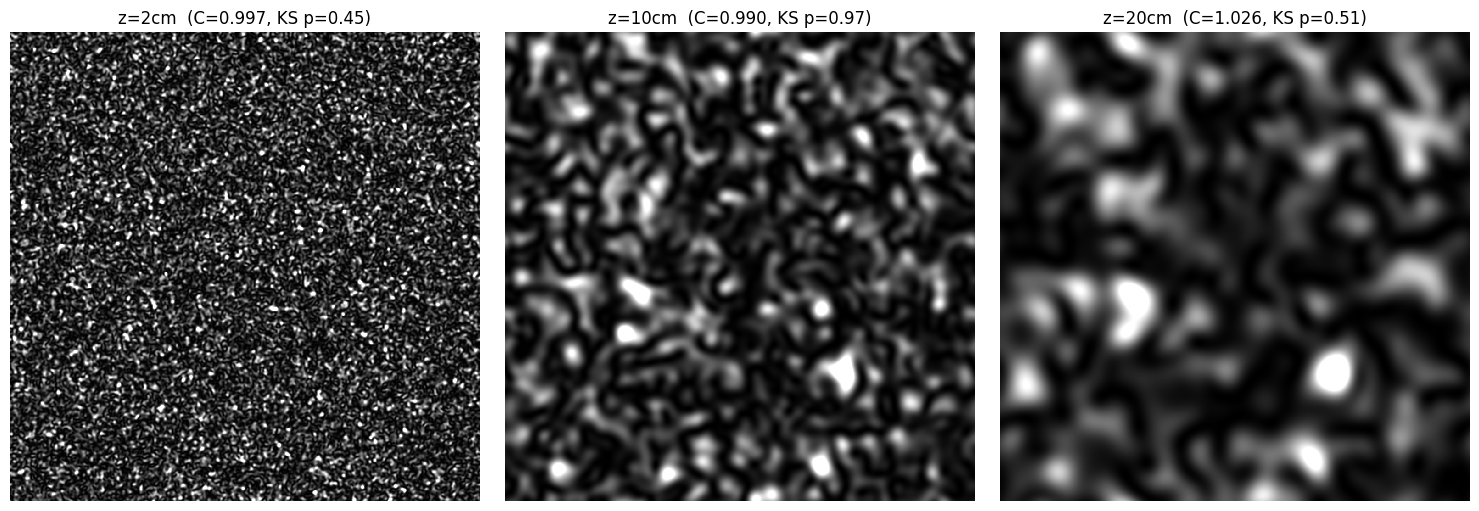

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, [0, 4, 9]):  # z=2cm, 10cm, 20cm
    r = results_log[idx]
    ax.imshow(frames[idx], cmap='gray', interpolation='nearest',
              vmin=0, vmax=np.percentile(frames[idx], 99))
    ax.set_title(f"z={DISTANCES_CM[idx]}cm  (C={r['contrast_C']:.3f}, KS p={r['ks_pvalue']:.2f})")
    ax.axis('off')
fig.tight_layout()
fig.savefig(get_figures_dir() / 'speckle_distancias_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Animación (GIF) - las 10 distancias en secuencia

Animacion guardada: C:\roberto\Tesis_Maestria\results\figures\speckle_distances\animacion.gif


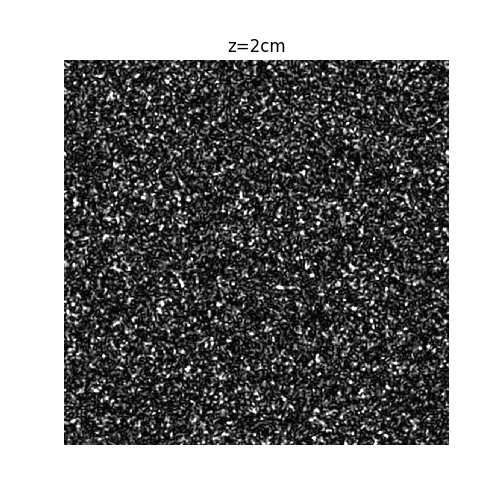

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0], cmap='gray', interpolation='nearest',
                vmin=0, vmax=np.percentile(frames[0], 99))
title = ax.set_title(f'z={DISTANCES_CM[0]}cm')
ax.axis('off')

def update(i):
    im.set_data(frames[i])
    im.set_clim(0, np.percentile(frames[i], 99))
    title.set_text(f'z={DISTANCES_CM[i]}cm')
    return im, title

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=600)
gif_path = IMG_DIR / 'animacion.gif'
ani.save(gif_path, writer=animation.PillowWriter(fps=2))
plt.close(fig)
print('Animacion guardada:', gif_path)
display(Image(filename=str(gif_path)))

## 6. Guardar parámetros y resultados

In [7]:
out_json = os.path.join('..', 'results', 'speckle_distances.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump({
        'lambda_m': LAMBDA, 'D_m': D, 'window_m': WINDOW_M, 'n_grid': N_GRID,
        'seed': SEED, 'distances_cm': DISTANCES_CM,
        'metodo': 'estadistico (ruido blanco gaussiano filtrado), NO propagacion de onda exacta',
        'validacion': 'contraste C y test KS (sobre muestra decorrelacionada al tamano de grano)',
        'resultados': results_log,
    }, f, indent=2, ensure_ascii=False)
print('Guardado:', out_json)

Guardado: ..\results\speckle_distances.json


## Estado y trabajo futuro

Este notebook, junto con la validación estadística de esta sección (contraste
$C$ y test KS en las 10 distancias), sostiene la Hipótesis (iii) y el
Objetivo específico 4 de la tesis. Reemplaza el enfoque original basado en
PINN (frontera de fase aleatoria resolviendo Helmholtz), que a la escala de
1 longitud de onda no lograba desarrollar speckle real -- ver
`scripts/experiments/diagnose_nb03_speckle_regime.py` para el diagnóstico
completo.

Pendiente: NB04 (antes NB05) -- benchmark cuantitativo de tiempo de inferencia
y memoria contra una implementación FEM de referencia (FEniCSx), para la
Hipótesis (ii) ($S = T_\text{FEM}/T_\text{PINN} > 1$).